In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Ler o CSV (ajuste o nome do arquivo)
df = pd.read_csv("Teste_ML.csv" , sep=";")

# 3. Remover valores inválidos (se tiver)
df = df.dropna()
df.columns = df.columns.str.strip()  # remove espaços
df.columns = df.columns.str.lower()  # deixa tudo minúsculo

# 4. Separar variáveis
X = df.select_dtypes(include=['number']).drop(columns=['glicose'])
y = df['glicose']

# 5. Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Criar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 7. Previsões
y_pred = modelo.predict(X_test)

# 8. Avaliar erro
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

# 9. Ver coeficientes
print("\nCoeficientes:")
for nome, coef in zip(X.columns, modelo.coef_):
    print(f"{nome}: {coef}")

print(f"\nIntercepto: {modelo.intercept_}")

RMSE: 2.707768845335505

Coeficientes:
passos: 0.001993923701944251
distancia_km: -3.0163779735510348
sono_horas: -0.8849876651238975
humor: -1.27321882678343
kcal: -0.006842400888529704
carboidrato: 0.09082593452673646
proteina: -0.04708622384460652
gordura: 0.1848190397192237
agua_ml: -0.0005424639537328232
treino: -5.584933010684772
deficit_kcal: -0.0003864461694566359

Intercepto: 115.86088820081014


In [15]:
print("Treino:", modelo.score(X_train, y_train))
print("Teste:", modelo.score(X_test, y_test))

# Exibe a confiança do modelo (Treino)

Treino: 0.9984777839938679
Teste: 0.6099993553314057


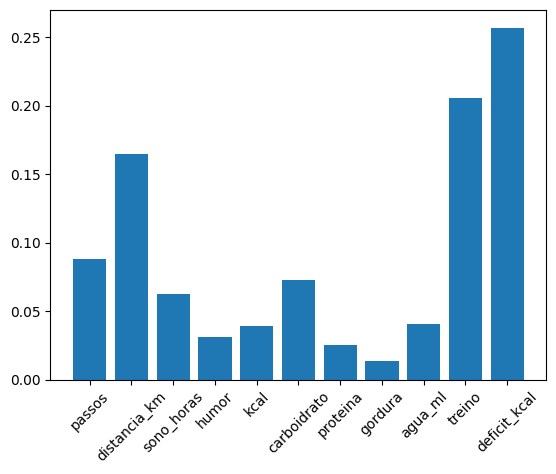

In [16]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Exibe a importancia de cada variavel para calcular o nivel de glicose

modelo = RandomForestRegressor()
modelo.fit(X_train, y_train)
importancias = modelo.feature_importances_
plt.bar(X.columns, importancias)
plt.xticks(rotation=45)
plt.show()